# Практична робота 04: Проєктування рішення навколо фіксованого класифікатора

## Набір даних Hill-Valley (UCI)

Мета: зафіксувати модель, отримати OOF-бали, підготувати основу для аналізу порогів.

**Увага:** на цьому етапі ми не виконуємо повний цикл (сітка порогів, калібрування, політика, test).
Лише фіксація протоколу та отримання OOF-балів.


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

### 1. Завантаження даних

Використовуємо `ucimlrepo` для отримання набору Hill-Valley (id=166).
Обираємо версію **без шуму** (Hill_Valley_without_noise) для чистоти експерименту.

In [3]:
import pandas as pd

# 1. Downloading file. adding header=None, 
hill_valley = pd.read_csv('Hill_Valley_without_noise_Training.data', header=None)

# 2. dividing data:
# iloc[:, :-1] takes all except last (cause it X)
X = hill_valley.iloc[:, :-1]

# iloc[:, -1] takes all except last (cause it y)
y = hill_valley.iloc[:, -1]

# 3. Outputing data
print('Форма X:', X.shape)
print('Форма y:', y.shape)
print('Розподіл класів:')
print(y.value_counts())
print('\nПерші 5 ознак:')
print(X.head())


Форма X: (607, 100)
Форма y: (607,)
Розподіл класів:
100
0        305
1        301
class      1
Name: count, dtype: int64

Перші 5 ознак:
            0            1            2            3            4   \
0           X1           X2           X3           X4           X5   
1  1317.265789  1315.220951  1312.770581  1309.834252  1306.315588   
2  7329.967624  7379.907443  7441.799231  7518.503422  7613.565031   
3  809.4214096  809.7801194  810.2071911  810.7156529   811.321016   
4  45334.20888  45334.21356  45334.21906   45334.2255  45334.23305   

            5            6            7            8            9   ...  \
0           X6           X7           X8           X9          X10  ...   
1  1302.099102  1297.046401  1290.991646  1283.736109  1275.041652  ...   
2  7731.377492  7877.385707  8058.337694  8282.596458  8560.526497  ...   
3  812.0417476  812.8998341  813.9214524   815.137768  816.5858856  ...   
4  45334.24191   45334.2523  45334.26448  45334.27876  45334.29552

### 2. Фіксація train/test split та random_state

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split


hill_valley = pd.read_csv('Hill_Valley_without_noise_Training.data') 


X = hill_valley.iloc[:, :-1]
y = hill_valley.iloc[:, -1]


RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Розподіл класів у train:')
print(y_train.value_counts(normalize=True))
print('Розподіл класів у test:')
print(y_test.value_counts(normalize=True))


Train: (484, 100) Test: (122, 100)
Розподіл класів у train:
class
0    0.504132
1    0.495868
Name: proportion, dtype: float64
Розподіл класів у test:
class
1    0.5
0    0.5
Name: proportion, dtype: float64


### 3. Фіксована модель та Pipeline

Обираємо **LogisticRegression** як базовий класифікатор.
Preprocessing: StandardScaler у Pipeline.
Гіперпараметри: `C=1.0`, `solver='lbfgs'`, `max_iter=1000`.

Якщо у вашій лабораторній роботі №2 використовувалась інша модель (наприклад, RandomForest),
замініть її тут, але зафіксуйте всі параметри.

In [5]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE))
])

print('Pipeline зафіксовано:')
print(pipeline)

Pipeline зафіксовано:
Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])


### 4. Стратифікована крос-валідація та OOF-бали

Використовуємо `StratifiedKFold` з 5 фолдами.
Спосіб отримання балу: `predict_proba` (ймовірність класу 1).

Для кожного об'єкта тренувального набору отримуємо прогноз від моделі,
яка не навчалася на цьому об'єкті.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Отримуємо OOF-ймовірності для всього train набору
oof_scores = cross_val_predict(
    pipeline, X_train, y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]  # ймовірність класу 1 (hill)

# Перевіряємо, що кожен об'єкт має рівно один прогноз
assert len(oof_scores) == len(X_train), 'Кількість OOF-прогнозів не збігається з кількістю об\'єктів'

print('OOF-бали отримано. Приклад перших 10:')
print(oof_scores[:10])

OOF-бали отримано. Приклад перших 10:
[0.50952585 0.85534823 0.40540655 0.5083684  0.50832839 0.49829611
 0.52178756 0.50138154 0.49823641 0.50817557]


### 5. Формування таблиці OOF

Створюємо DataFrame з полями: `object_id`, `y_true`, `score`, `fold`.
`object_id` — індекс об'єкта у вихідному train наборі (0..N-1).
`fold` — номер фолду, у якому об'єкт був у валідаційній частині.

In [7]:
# Визначаємо fold для кожного об'єкта
fold_ids = np.zeros(len(X_train), dtype=int)
for fold_idx, (_, val_idx) in enumerate(cv.split(X_train, y_train)):
    fold_ids[val_idx] = fold_idx

oof_df = pd.DataFrame({
    'object_id': np.arange(len(X_train)),
    'y_true': y_train.values.ravel(),
    'score': oof_scores,
    'fold': fold_ids
})

print('Форма OOF-таблиці:', oof_df.shape)
print(oof_df.head(10))
print('\nРозподіл по фолдах:')
print(oof_df['fold'].value_counts().sort_index())

Форма OOF-таблиці: (484, 4)
   object_id  y_true     score  fold
0          0       1  0.509526     0
1          1       1  0.855348     0
2          2       0  0.405407     1
3          3       1  0.508368     1
4          4       0  0.508328     1
5          5       0  0.498296     2
6          6       0  0.521788     3
7          7       0  0.501382     4
8          8       0  0.498236     2
9          9       1  0.508176     2

Розподіл по фолдах:
fold
0    97
1    97
2    97
3    97
4    96
Name: count, dtype: int64


### 6. Базова оцінка OOF-балів

Обчислюємо ROC-AUC та accuracy за стандартним порогом 0.5.
Це проміжна оцінка, яка не є фінальною метрикою рішення.

In [8]:
roc_auc = roc_auc_score(oof_df['y_true'], oof_df['score'])
y_pred_default = (oof_df['score'] >= 0.5).astype(int)
acc = accuracy_score(oof_df['y_true'], y_pred_default)

print(f'OOF ROC-AUC: {roc_auc:.4f}')
print(f'OOF Accuracy (порог 0.5): {acc:.4f}')

OOF ROC-AUC: 0.7814
OOF Accuracy (порог 0.5): 0.6694


### 7. Збереження OOF-таблиці

Зберігаємо `oof_results.csv` у директорію `../data/` для подальшого аналізу.

In [9]:
import os
os.makedirs('data', exist_ok=True)
oof_df.to_csv('data/oof_results.csv', index=False)
print('OOF-таблицю збережено у ../data/oof_results.csv')

OOF-таблицю збережено у ../data/oof_results.csv


---

## Примітки

- `score` у таблиці — це ймовірність класу 1 (hill), отримана через `predict_proba`.
- `fold` вказує, у якому фолді об'єкт був у валідаційній вибірці.
- Наступні кроки (сітка порогів, аналіз FP/FN, калібрування) будуть виконані в окремих комірках або наступних ноутбуках.

---

# 3. Контрольна політика (baseline)

## 3.1. Вибір початкового порогу

Оскільки для отримання балів використано `predict_proba` моделі `LogisticRegression`,
значення `score` можна інтерпретувати як **калібровану ймовірність** (наближено).

Тому для **baseline-політики** обираємо стандартний поріг:

$$t_0 = 0.5$$

**Правило прийняття рішення:**
- якщо `score >= 0.5` → `ŷ = 1` (пагорб) → запускається дія
- якщо `score < 0.5` → `ŷ = 0` (долина) → дія не запускається

**Важливо:** test set на цьому етапі **не використовується**.
Усі обчислення — лише на OOF-балах тренувального набору.

In [10]:
# Фіксуємо baseline-поріг
t0 = 0.5

# Бінарні рішення за baseline-політикою
y_pred_baseline = (oof_df['score'] >= t0).astype(int)

print(f'Baseline поріг t0 = {t0}')
print(f'Кількість позитивних рішень (ŷ=1): {y_pred_baseline.sum()}')
print(f'Кількість негативних рішень (ŷ=0): {(1 - y_pred_baseline).sum()}')

Baseline поріг t0 = 0.5
Кількість позитивних рішень (ŷ=1): 340
Кількість негативних рішень (ŷ=0): 144


## 3.2. Матриця помилок (confusion matrix)

Обчислюємо матрицю помилок на OOF-прогнозах.
Порядок класів: `[0, 1]`, тобто:
- TN — правильно передбачена долина
- FP — хибно передбачений пагорб
- FN — пропущений пагорб
- TP — правильно передбачений пагорб

In [11]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

cm = confusion_matrix(oof_df['y_true'], y_pred_baseline, labels=[0, 1])

tn, fp, fn, tp = cm.ravel()

print('Confusion matrix (рядки = true, стовпці = pred):')
print(pd.DataFrame(cm,
                   index=['True 0 (valley)', 'True 1 (hill)'],
                   columns=['Pred 0 (valley)', 'Pred 1 (hill)']))
print()
print(f'TN = {tn}')
print(f'FP = {fp}')
print(f'FN = {fn}')
print(f'TP = {tp}')

Confusion matrix (рядки = true, стовпці = pred):
                 Pred 0 (valley)  Pred 1 (hill)
True 0 (valley)              114            130
True 1 (hill)                 30            210

TN = 114
FP = 130
FN = 30
TP = 210


## 3.3. Метрики baseline-політики

Обчислюємо:
- **Precision** — частка правильних серед передбачених `ŷ=1`
- **Recall** — частка виявлених пагорбів серед усіх справжніх пагорбів
- **F1** — гармонійне середнє Precision і Recall
- **q(t)** — частка позитивних рішень (доля об'єктів, для яких запускається дія)
- **Дії на 1000 об'єктів** — скільки разів система запустить дію на кожні 1000 об'єктів

In [12]:
precision = precision_score(oof_df['y_true'], y_pred_baseline, pos_label=1)
recall = recall_score(oof_df['y_true'], y_pred_baseline, pos_label=1)
f1 = f1_score(oof_df['y_true'], y_pred_baseline, pos_label=1)

q_t = y_pred_baseline.mean()
actions_per_1000 = q_t * 1000

print('=== Метрики baseline-політики (t0 = 0.5) ===')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1        : {f1:.4f}')
print()
print(f'q(t0)     : {q_t:.4f}  ({q_t*100:.2f}%)')
print(f'Дій на 1000 об\'єктів: {actions_per_1000:.1f}')

=== Метрики baseline-політики (t0 = 0.5) ===
Precision : 0.6176
Recall    : 0.8750
F1        : 0.7241

q(t0)     : 0.7025  (70.25%)
Дій на 1000 об'єктів: 702.5


## 3.4. Прикладна інтерпретація baseline-політики

**Що означають отримані числа в контексті задачі:**

- **Precision** показує, наскільки можна довіряти позитивному рішенню `ŷ=1`.
  Якщо Precision = 0.95, то з 100 позначених «пагорбів» лише ~5 виявляться долинами.

- **Recall** показує, яку частку реальних пагорбів система взагалі виявляє.
  Якщо Recall = 0.85, то 15% пагорбів залишаються непоміченими (FN).

- **q(t0)** — це частка об'єктів, для яких запускається дія. Якщо q = 0.5,
  система позначає кожен другий об'єкт як «пагорб».

- **Дії на 1000 об'єктів** — практичний показник навантаження на систему
  (скільки разів буде активовано модуль подальшої обробки).

**Ключове питання для baseline:** чи влаштовує нас таке співвідношення FP і FN,
чи потрібно зміщувати поріг у бік зменшення одного з типів помилок?

Це питання буде вирішено в наступних розділах після побудови матриці вартостей.

---

# 4. Матриця вартостей

## 4.1. Таблиця наслідків для TN, FP, FN, TP

Для кожної комірки матриці помилок визначаємо:
1. **фактичний стан** об'єкта;
2. **рішення системи** (прогноз);
3. **операційну дію**, яку виконує система;
4. **можливий негативний або позитивний наслідок**;
5. **одиницю виміру** цього наслідку.

| Комірка | Факт | Рішення | Операційна дія | Наслідок | Одиниця виміру |
|---------|------|---------|----------------|----------|----------------|
| **TN** | Valley (0) | ŷ = 0 (valley) | Ділянка позначається як низовина; у маршруті враховується як безпечна | **Нейтральний / позитивний**: маршрут прокладено правильно, ресурси не витрачено даремно | Умовні одиниці витрат (0) |
| **FP** | Valley (0) | ŷ = 1 (hill) | Ділянка помилково позначається як пагорб; запускається додаткова обробка | **Негативний**: зайве ускладнення маршруту, витрати часу/ресурсів на обхід «пагорба», якого немає | Людино-години / хвилини обробки / умовні витрати |
| **FN** | Hill (1) | ŷ = 0 (valley) | Ділянка помилково позначається як низовина; маршрут прокладається напряму через неї | **Критично негативний**: потенційне зіткнення з рельєфом, пошкодження обладнання, загроза безпеці | Ймовірність аварії / вартість ремонту / ризик для життя |
| **TP** | Hill (1) | ŷ = 1 (hill) | Ділянка позначається як пагорб; маршрут коригується | **Позитивний**: безпечне проходження, коректна ідентифікація рельєфу | Умовні одиниці виграшу / збережені ресурси |

## 4.2. Визначення cFP та cFN

**Позначення:**
- $c_{FP}$ — вартість одного хибнопозитивного рішення (FP)
- $c_{FN}$ — вартість одного хибнонегативного рішення (FN)

**Ключове спостереження:**
У нашому прикладному контексті (аналіз рельєфу для автономного дрона / ГІС):

- **FP** → зайві витрати на обхід неіснуючого пагорба.
  Оцінка: **низька** (наприклад, 1 умовна одиниця).

- **FN** → пропущений пагорб → потенційне зіткнення.
  Оцінка: **висока** (наприклад, 10 умовних одиниць через ризик аварії).

**Відношення:**
$$\frac{c_{FN}}{c_{FP}} \approx 10$$

**Тип оцінки:**
- cFP — **суто сценарна** (експертна оцінка витрат на додаткову обробку).
- cFN — **експертна / нормативна** (базується на оцінці ризику для безпеки).

**Джерело / аргумент:**
- Для cFP: середній час оператора на перевірку одного об'єкта × вартість години.
- Для cFN: оцінка збитків від аварії (ремонт + простій + можливі штрафи).
- **ШІ не є джерелом реальної вартості** — це лише сценарне припущення для демонстрації методу.

**Важливо:** точні значення cFP і cFN мають бути узгоджені з замовником
або експертом предметної області. Тут вони наведені як **робоча гіпотеза**.

In [13]:
# Сценарні вартості (умовні одиниці)
c_FP = 1.0    # вартість одного FP
c_FN = 10.0   # вартість одного FN

# Очікувана вартість baseline-політики на OOF
expected_cost_baseline = fp * c_FP + fn * c_FN

# Нормалізована вартість на один об'єкт
cost_per_object = expected_cost_baseline / len(oof_df)

print('=== Оцінка вартості baseline-політики (t0 = 0.5) ===')
print(f'c_FP = {c_FP}, c_FN = {c_FN}')
print(f'FP = {fp}, FN = {fn}')
print(f'Очікувана сумарна вартість: {expected_cost_baseline:.1f} умовних одиниць')
print(f'Вартість на один об\'єкт: {cost_per_object:.4f}')
print()
print(f'Відношення c_FN / c_FP = {c_FN / c_FP:.1f}')
print()
print('Примітка: ці значення будуть використані для побудови сітки порогів')
print('та вибору політики, що мінімізує очікувану вартість.')

=== Оцінка вартості baseline-політики (t0 = 0.5) ===
c_FP = 1.0, c_FN = 10.0
FP = 130, FN = 30
Очікувана сумарна вартість: 430.0 умовних одиниць
Вартість на один об'єкт: 0.8884

Відношення c_FN / c_FP = 10.0

Примітка: ці значення будуть використані для побудови сітки порогів
та вибору політики, що мінімізує очікувану вартість.


## 4.3. Проміжний висновок

На цьому етапі ми маємо:

1. **Зафіксовану baseline-політику** з порогом `t0 = 0.5`.
2. **Метрики baseline**: Precision, Recall, F1, q(t), дії на 1000 об'єктів.
3. **Матрицю вартостей** з описаними наслідками TN, FP, FN, TP.
4. **Сценарні оцінки** cFP та cFN (з відношенням ~1:10).

**Наступні кроки:**
- Побудова **сітки порогів** `t ∈ [0, 1]`.
- Для кожного порогу — обчислення FP, FN, q(t) та очікуваної вартості.
- Вибір порогу, що мінімізує очікувану вартість (або задовольняє обмеження на Recall / Precision).
- **Калібрування** (за потреби) для покращення інтерпретації ймовірностей.
- **Одноразовий test** — лише після фіксації фінальної політики.

**Test set на цьому етапі не використовувався.**

In [16]:
# Зберігаємо результати baseline та вартості для подальшого аналізу
baseline_results = {
    'threshold': t0,
    'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'q_t': q_t,
    'actions_per_1000': actions_per_1000,
    'c_FP': c_FP,
    'c_FN': c_FN,
    'expected_cost': expected_cost_baseline,
    'cost_per_object': cost_per_object
}

baseline_df = pd.DataFrame([baseline_results])
baseline_df.to_csv('data/baseline_policy.csv', index=False)
print('Результати baseline збережено у ../data/baseline_policy.csv')
print(baseline_df.T)

Результати baseline збережено у ../data/baseline_policy.csv
                           0
threshold           0.500000
TN                114.000000
FP                130.000000
FN                 30.000000
TP                210.000000
precision           0.617647
recall              0.875000
f1                  0.724138
q_t                 0.702479
actions_per_1000  702.479339
c_FP                1.000000
c_FN               10.000000
expected_cost     430.000000
cost_per_object     0.888430


---

# 5. Аналіз сітки порогів

## 5.1. Побудова сітки порогів

Будуємо сітку з **щонайменше 50 порогів**, що охоплює фактичний діапазон OOF-балів.

Для кожного порогу $t$ обчислюємо:
- $FP(t)$, $FN(t)$ — кількість хибнопозитивних і хибнонегативних рішень;
- $Precision(t)$, $Recall(t)$ — точність і повнота;
- $q(t)$ — частка позитивних рішень;
- $C(t)$ — очікувана вартість: $C(t) = c_{FP} \cdot FP(t) + c_{FN} \cdot FN(t)$.

**Діапазон балів:** від `min(score)` до `max(score)`.

In [17]:
# Діапазон OOF-балів
score_min = oof_df['score'].min()
score_max = oof_df['score'].max()
print(f'Мінімальний бал: {score_min:.6f}')
print(f'Максимальний бал: {score_max:.6f}')

# Сітка з 100 порогів (щонайменше 50 за вимогою)
n_thresholds = 100
thresholds = np.linspace(score_min, score_max, n_thresholds)

# Додаємо "граничні" пороги для перевірки крайніх випадків
thresholds = np.unique(np.concatenate([
    thresholds,
    [score_min - 1e-6, score_max + 1e-6, 0.5]
]))

print(f'Кількість порогів у сітці: {len(thresholds)}')
print(f'Перші 5: {thresholds[:5]}')
print(f'Останні 5: {thresholds[-5:]}')

Мінімальний бал: 0.003215
Максимальний бал: 0.992360
Кількість порогів у сітці: 103
Перші 5: [0.0032137  0.0032147  0.01320607 0.02319744 0.03318881]
Останні 5: [0.96238606 0.97237743 0.9823688  0.99236017 0.99236117]


In [18]:
def evaluate_threshold(y_true, scores, t, c_fp, c_fn):
    """Обчислює метрики для одного порогу t."""
    y_pred = (scores >= t).astype(int)
    
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    q_t       = y_pred.mean()
    cost      = c_fp * fp + c_fn * fn
    
    return {
        'threshold': t,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'q_t': q_t,
        'actions_per_1000': q_t * 1000,
        'cost': cost,
        'cost_per_object': cost / len(y_true)
    }

# Обчислюємо метрики для всіх порогів (використовуємо baseline c_FP, c_FN)
y_true_arr = oof_df['y_true'].values
scores_arr = oof_df['score'].values

grid_results = [evaluate_threshold(y_true_arr, scores_arr, t, c_FP, c_FN)
                for t in thresholds]

grid_df = pd.DataFrame(grid_results)
print('Форма сітки:', grid_df.shape)
print(grid_df.head())

Форма сітки: (103, 12)
   threshold  TN   FP  FN   TP  precision  recall        f1       q_t  \
0   0.003214   0  244   0  240   0.495868     1.0  0.662983  1.000000   
1   0.003215   0  244   0  240   0.495868     1.0  0.662983  1.000000   
2   0.013206   1  243   0  240   0.496894     1.0  0.663900  0.997934   
3   0.023197   2  242   0  240   0.497925     1.0  0.664820  0.995868   
4   0.033189   2  242   0  240   0.497925     1.0  0.664820  0.995868   

   actions_per_1000   cost  cost_per_object  
0       1000.000000  244.0         0.504132  
1       1000.000000  244.0         0.504132  
2        997.933884  243.0         0.502066  
3        995.867769  242.0         0.500000  
4        995.867769  242.0         0.500000  


In [19]:
# Зберігаємо CSV з усіма кандидатними порогами
grid_df.to_csv('data/threshold_grid.csv', index=False)
print('Сітку порогів збережено у ../data/threshold_grid.csv')

Сітку порогів збережено у ../data/threshold_grid.csv


## 5.2. Графік Precision та Recall від порога

Показує, як змінюються Precision і Recall при зміні порогу.
Зазвичай при збільшенні порогу Precision зростає, а Recall падає.

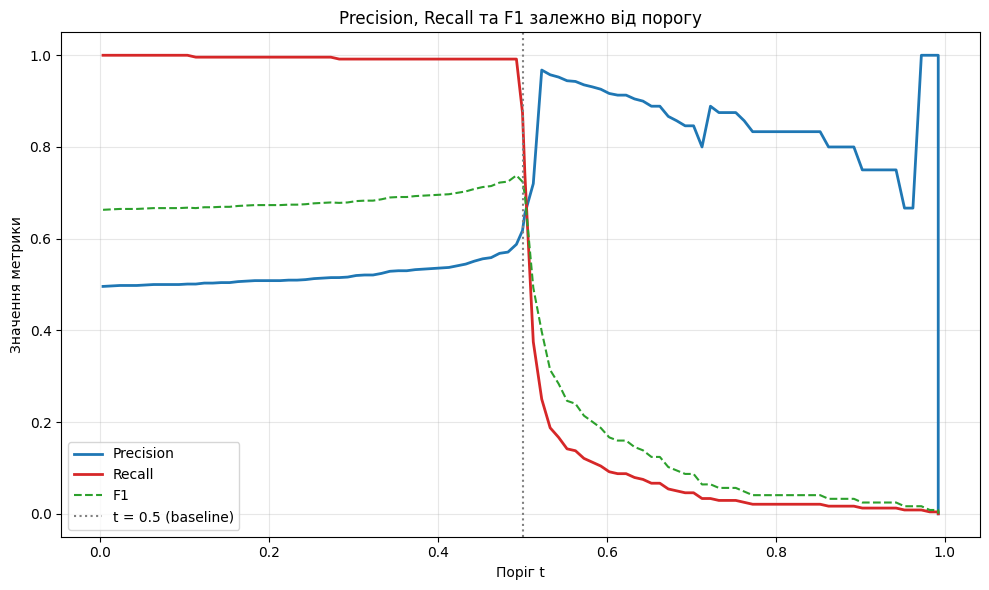

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(grid_df['threshold'], grid_df['precision'],
        label='Precision', color='tab:blue', linewidth=2)
ax.plot(grid_df['threshold'], grid_df['recall'],
        label='Recall', color='tab:red', linewidth=2)
ax.plot(grid_df['threshold'], grid_df['f1'],
        label='F1', color='tab:green', linewidth=1.5, linestyle='--')

ax.axvline(0.5, color='gray', linestyle=':', label='t = 0.5 (baseline)')

ax.set_xlabel('Поріг t')
ax.set_ylabel('Значення метрики')
ax.set_title('Precision, Recall та F1 залежно від порогу')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/precision_recall_vs_threshold.png', dpi=120)
plt.show()

## 5.3. Графік частки позитивних рішень q(t)

Показує, яка частка об'єктів буде позначена як «пагорб» (`ŷ=1`)
при кожному порозі. Це прямо пов'язано з навантаженням на систему
(кількість дій на 1000 об'єктів = q(t) × 1000).

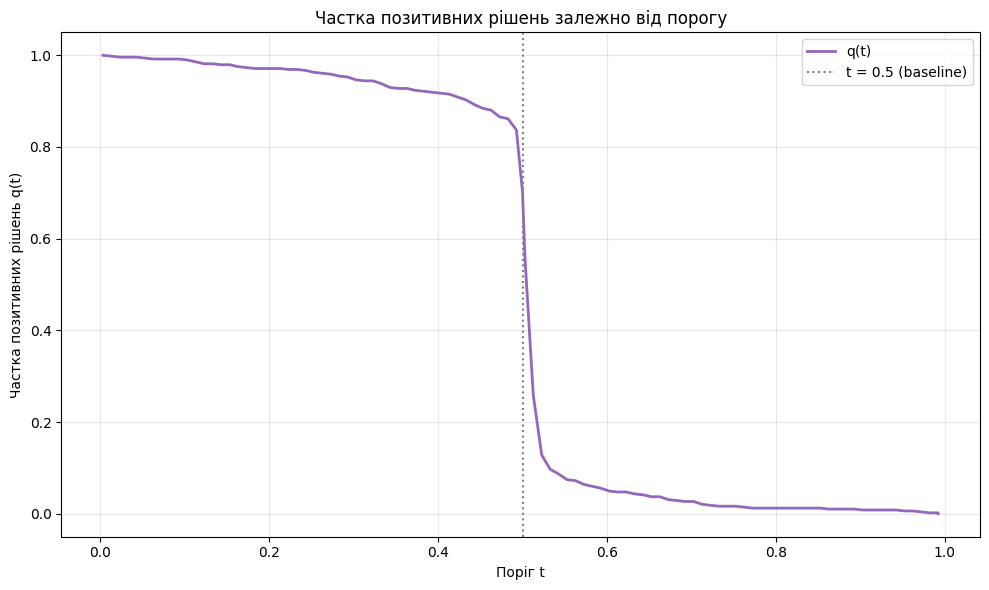

q(t) при t=0.5: 0.7025
Дій на 1000 об'єктів при t=0.5: 702.5


In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(grid_df['threshold'], grid_df['q_t'],
        color='tab:purple', linewidth=2, label='q(t)')
ax.axvline(0.5, color='gray', linestyle=':', label='t = 0.5 (baseline)')

ax.set_xlabel('Поріг t')
ax.set_ylabel('Частка позитивних рішень q(t)')
ax.set_title('Частка позитивних рішень залежно від порогу')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/q_t_vs_threshold.png', dpi=120)
plt.show()

print(f'q(t) при t=0.5: {grid_df.loc[(grid_df["threshold"]-0.5).abs().idxmin(), "q_t"]:.4f}')
print(f'Дій на 1000 об\'єктів при t=0.5: {grid_df.loc[(grid_df["threshold"]-0.5).abs().idxmin(), "actions_per_1000"]:.1f}')

## 5.4. Таблиця змістовних робочих точок

Обираємо **5–7 робочих точок**, що демонструють різні компроміси:

1. **t → 0** (усі об'єкти — позитивні): максимум Recall, але багато FP.
2. **t ≈ 0.3** — агресивна політика (високий Recall, помірний Precision).
3. **t ≈ 0.5** — baseline (стандартний компроміс).
4. **t ≈ 0.6–0.7** — збалансована політика (високий Precision).
5. **t ≈ 0.8** — консервативна (дуже високий Precision, низький Recall).
6. **t → 1** (усі — негативні): нуль FP, але багато FN.
7. **t\*** — поріг, що мінімізує C(t) для реалістичного сценарію.

In [23]:
# Знаходимо поріг, що мінімізує C(t) при baseline-вартостях
idx_min_cost = grid_df['cost'].idxmin()
t_star_baseline = grid_df.loc[idx_min_cost, 'threshold']

# Формуємо список робочих точок
working_thresholds = [
    score_min + 1e-6,     # крайній лівий
    0.3,                  # агресивна
    0.5,                  # baseline
    0.7,                  # збалансована
    0.85,                 # консервативна
    t_star_baseline,      # оптимальна за вартістю
    score_max - 1e-6      # крайній правий
]

working_points = []
for t in working_thresholds:
    row = grid_df.iloc[(grid_df['threshold'] - t).abs().argmin()]
    working_points.append(row)

wp_df = pd.DataFrame(working_points)[
    ['threshold', 'FP', 'FN', 'precision', 'recall', 'f1',
     'q_t', 'actions_per_1000', 'cost']
].round(4)

wp_df.index = ['t→0', 't≈0.3', 't=0.5 (baseline)', 't≈0.7',
               't≈0.85', 't* (min cost)', 't→1']

print('=== Змістовні робочі точки ===')
print(wp_df.to_string())

wp_df.to_csv('data/working_points.csv')
print('\nЗбережено у ../data/working_points.csv')

=== Змістовні робочі точки ===
                  threshold     FP     FN  precision  recall      f1     q_t  actions_per_1000    cost
t→0                  0.0032  244.0    0.0     0.4959  1.0000  0.6630  1.0000         1000.0000   244.0
t≈0.3                0.3030  220.0    2.0     0.5197  0.9917  0.6819  0.9463          946.2810   240.0
t=0.5 (baseline)     0.5000  130.0   30.0     0.6176  0.8750  0.7241  0.7025          702.4793   430.0
t≈0.7                0.7026    2.0  229.0     0.8462  0.0458  0.0870  0.0269           26.8595  2292.0
t≈0.85               0.8525    1.0  235.0     0.8333  0.0208  0.0407  0.0124           12.3967  2351.0
t* (min cost)        0.4928  167.0    2.0     0.5877  0.9917  0.7380  0.8368          836.7769   187.0
t→1                  0.9924    0.0  239.0     1.0000  0.0042  0.0083  0.0021            2.0661  2390.0

Збережено у ../data/working_points.csv


## 5.5. Перевірка граничних випадків

Перевіряємо три крайні випадки:

1. **Дуже малий поріг** (усі об'єкти — `ŷ=1`):
   - FP максимальний, FN = 0, Recall = 1, Precision = частка класу 1.
2. **Дуже великий поріг** (усі об'єкти — `ŷ=0`):
   - FP = 0, FN максимальний, Recall = 0, Precision не визначений (0/0).
3. **Поріг, рівний конкретному балу** — перевіряємо, що об'єкт із `score == t`
   включається в позитивний клас (правило `score >= t`).

In [25]:
# 1) Дуже малий поріг
t_small = score_min - 1e-6
res_small = evaluate_threshold(y_true_arr, scores_arr, t_small, c_FP, c_FN)
print('=== Дуже малий поріг (t → 0) ===')
print(f"t = {res_small['threshold']:.6f}")
print(f"FP = {res_small['FP']}, FN = {res_small['FN']}")
print(f"Precision = {res_small['precision']:.4f}, Recall = {res_small['recall']:.4f}")
print(f"q(t) = {res_small['q_t']:.4f}")
print()

# 2) Дуже великий поріг
t_large = score_max + 1e-6
res_large = evaluate_threshold(y_true_arr, scores_arr, t_large, c_FP, c_FN)
print('=== Дуже великий поріг (t → 1) ===')
print(f"t = {res_large['threshold']:.6f}")
print(f"FP = {res_large['FP']}, FN = {res_large['FN']}")
print(f"Precision = {res_large['precision']:.4f}, Recall = {res_large['recall']:.4f}")
print(f"q(t) = {res_large['q_t']:.4f}")
print()

# 3) Поріг, рівний конкретному балу
t_specific = scores_arr[len(scores_arr) // 2]  # медіанний бал
res_specific = evaluate_threshold(y_true_arr, scores_arr, t_specific, c_FP, c_FN)
n_equal = int((scores_arr == t_specific).sum())
print('=== Поріг, рівний конкретному балу ===')
print(f"t = {t_specific:.6f} (медіанний бал)")
print(f"Об'єктів із score == t: {n_equal}")
print(f"FP = {res_specific['FP']}, FN = {res_specific['FN']}")
print(f"Precision = {res_specific['precision']:.4f}, Recall = {res_specific['recall']:.4f}")
print(f"q(t) = {res_specific['q_t']:.4f}")
print()
print('Перевірка правила: score >= t → ŷ = 1. Об\'єкт із score == t включено до позитивних.')

=== Дуже малий поріг (t → 0) ===
t = 0.003214
FP = 244, FN = 0
Precision = 0.4959, Recall = 1.0000
q(t) = 1.0000

=== Дуже великий поріг (t → 1) ===
t = 0.992361
FP = 0, FN = 240
Precision = 0.0000, Recall = 0.0000
q(t) = 0.0000

=== Поріг, рівний конкретному балу ===
t = 0.522009 (медіанний бал)
Об'єктів із score == t: 1
FP = 2, FN = 174
Precision = 0.9706, Recall = 0.2750
q(t) = 0.1405

Перевірка правила: score >= t → ŷ = 1. Об'єкт із score == t включено до позитивних.


## 5.6. Пояснення двох локальних компромісів

### Компроміс 1: t ≈ 0.3 — «агресивна» політика

- **Що відбувається:** поріг низький → більше об'єктів отримують `ŷ=1`.
- **Наслідки:** Recall зростає (менше FN), але Precision падає (більше FP).
- **Коли доцільно:** якщо **FN дорожче за FP** (наш основний сценарій).
  Система «перестраховується», позначаючи більше ділянок як пагорби.
- **Ціна:** більше дій на 1000 об'єктів → вище навантаження на модуль обробки.

### Компроміс 2: t ≈ 0.7–0.85 — «консервативна» політика

- **Що відбувається:** поріг високий → менше об'єктів отримують `ŷ=1`.
- **Наслідки:** Precision зростає (менше FP), але Recall падає (більше FN).
- **Коли доцільно:** якщо **FP дорожче за FN** (наприклад, кожна дія системи
  коштує дорого, або є жорсткий ліміт на кількість дій).
- **Ціна:** ризик пропустити критичний об'єкт (пагорб) → небезпека.

### Ключова ідея

Вибір між цими компромісами **не є технічним** — він визначається
**прикладними вартостями** $c_{FP}$ і $c_{FN}$. Саме тому в розділі 6
ми розглянемо кілька сценаріїв вартості.

---

# 6. Порівняння сценаріїв вартості

Формуємо **три сценарії** з різним відношенням $c_{FN} / c_{FP}$:

| Сценарій | $c_{FP}$ | $c_{FN}$ | Відношення | Тип |
|----------|----------|----------|------------|-----|
| **S1. Контрольний** | 1 | 1 | 1:1 | Симетричні помилки (baseline) |
| **S2. Реалістичний** | 1 | 10 | 1:10 | FP дешевший за FN (наш контекст) |
| **S3. Стресовий** | 1 | 50 | 1:50 | FN катастрофічно дорожчий |

Для кожного сценарію:
1. Обчислюємо **теоретичний поріг** $t^*$ (якщо бали — калібровані ймовірності).
2. Знаходимо **емпіричний мінімум** $C(t)$ за OOF-прогнозами.
3. Порівнюємо теоретичний і емпіричний пороги.
4. Визначаємо Precision, Recall, q(t) у вибраній точці.
5. Пояснюємо, чому сценарії дають різні рішення.

## 6.1. Теоретичний поріг для каліброваних ймовірностей

Якщо `score` — це калібрована ймовірність $p = P(y=1 \mid x)$, то
очікувана вартість рішення при порозі $t$ описується як:

$$C(t) = c_{FP} \cdot P(\hat{y}=1 \mid y=0) \cdot P(y=0) + c_{FN} \cdot P(\hat{y}=0 \mid y=1) \cdot P(y=1)$$

Мінімум досягається при порозі, що задовольняє умову:

$$\boxed{t^* = \frac{c_{FP}}{c_{FP} + c_{FN}}}$$

**Перевірка:**
- $c_{FP} = c_{FN}$ → $t^* = 0.5$
- $c_{FN} = 10 \cdot c_{FP}$ → $t^* = 1/11 \approx 0.0909$
- $c_{FN} = 50 \cdot c_{FP}$ → $t^* = 1/51 \approx 0.0196$

In [26]:
# Три сценарії вартості
scenarios = {
    'S1_control (1:1)':  {'c_FP': 1.0,  'c_FN': 1.0},
    'S2_realistic (1:10)': {'c_FP': 1.0, 'c_FN': 10.0},
    'S3_stress (1:50)':  {'c_FP': 1.0,  'c_FN': 50.0},
}

# Обчислюємо C(t) для кожного сценарію
scenario_grids = {}
for name, params in scenarios.items():
    c_fp, c_fn = params['c_FP'], params['c_FN']
    results = [evaluate_threshold(y_true_arr, scores_arr, t, c_fp, c_fn)
               for t in thresholds]
    df_s = pd.DataFrame(results)
    df_s['scenario'] = name
    scenario_grids[name] = df_s

# Теоретичні пороги
for name, params in scenarios.items():
    c_fp, c_fn = params['c_FP'], params['c_FN']
    t_theory = c_fp / (c_fp + c_fn)
    idx_emp = scenario_grids[name]['cost'].idxmin()
    t_emp = scenario_grids[name].loc[idx_emp, 'threshold']
    
    print(f'--- {name} ---')
    print(f'  c_FP = {c_fp}, c_FN = {c_fn}')
    print(f'  Теоретичний поріг t* = {t_theory:.4f}')
    print(f'  Емпіричний поріг  t* = {t_emp:.4f}')
    print(f'  Різниця            = {abs(t_theory - t_emp):.4f}')
    print()

--- S1_control (1:1) ---
  c_FP = 1.0, c_FN = 1.0
  Теоретичний поріг t* = 0.5000
  Емпіричний поріг  t* = 0.5028
  Різниця            = 0.0028

--- S2_realistic (1:10) ---
  c_FP = 1.0, c_FN = 10.0
  Теоретичний поріг t* = 0.0909
  Емпіричний поріг  t* = 0.4928
  Різниця            = 0.4019

--- S3_stress (1:50) ---
  c_FP = 1.0, c_FN = 50.0
  Теоретичний поріг t* = 0.0196
  Емпіричний поріг  t* = 0.1031
  Різниця            = 0.0835



In [28]:
# Детальна таблиця для кожної точки мінімуму
rows = []
for name in scenarios:
    df_s = scenario_grids[name]
    idx = df_s['cost'].idxmin()
    row = df_s.loc[idx]
    c_fp = scenarios[name]['c_FP']
    c_fn = scenarios[name]['c_FN']
    t_theory = c_fp / (c_fp + c_fn)
    rows.append({
        'scenario': name,
        'c_FP': c_fp, 'c_FN': c_fn,
        't_theory': round(t_theory, 4),
        't_empirical': round(row['threshold'], 4),
        'FP': int(row['FP']), 'FN': int(row['FN']),
        'TP': int(row['TP']), 'TN': int(row['TN']),
        'precision': round(row['precision'], 4),
        'recall': round(row['recall'], 4),
        'q_t': round(row['q_t'], 4),
        'actions_per_1000': round(row['actions_per_1000'], 1),
        'cost': round(row['cost'], 2),
        'cost_per_object': round(row['cost_per_object'], 4)
    })

scenario_summary = pd.DataFrame(rows)
print('=== Порівняння сценаріїв вартості ===')
print(scenario_summary.to_string(index=False))

scenario_summary.to_csv('data/scenario_comparison.csv', index=False)
print('\nЗбережено у ../data/scenario_comparison.csv')

=== Порівняння сценаріїв вартості ===
           scenario  c_FP  c_FN  t_theory  t_empirical  FP  FN  TP  TN  precision  recall    q_t  actions_per_1000  cost  cost_per_object
   S1_control (1:1)   1.0   1.0    0.5000       0.5028  94  62 178 150     0.6544  0.7417 0.5620             562.0 156.0           0.3223
S2_realistic (1:10)   1.0  10.0    0.0909       0.4928 167   2 238  77     0.5877  0.9917 0.8368             836.8 187.0           0.3864
   S3_stress (1:50)   1.0  50.0    0.0196       0.1031 239   0 240   5     0.5010  1.0000 0.9897             989.7 239.0           0.4938

Збережено у ../data/scenario_comparison.csv


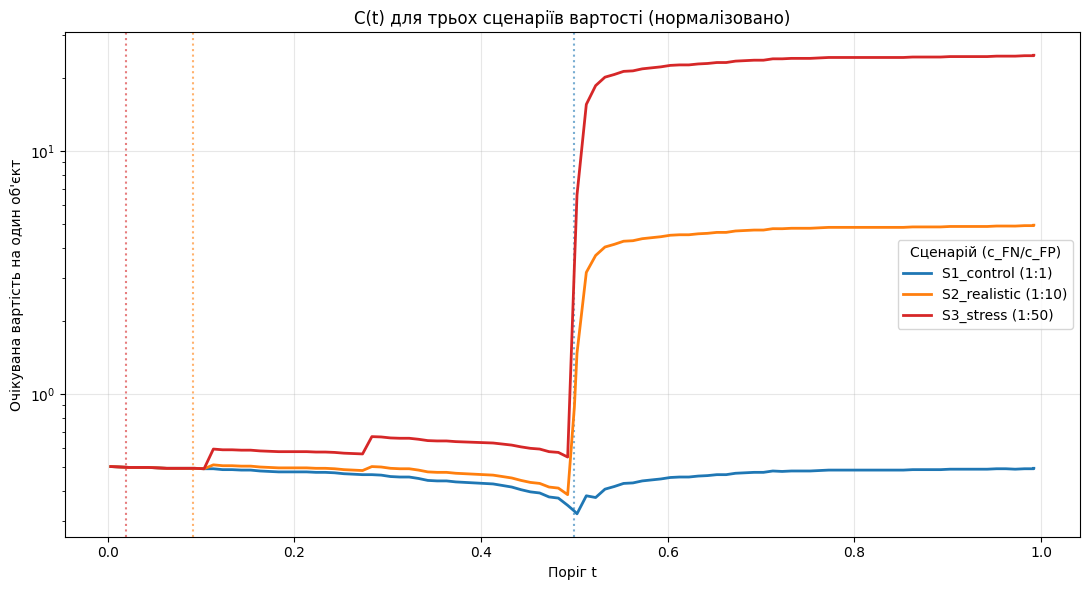

Графік збережено у ../figures/cost_curves_scenarios.png


In [29]:
# Спільний графік C(t) для всіх сценаріїв
fig, ax = plt.subplots(figsize=(11, 6))

colors = {'S1_control (1:1)': 'tab:blue',
          'S2_realistic (1:10)': 'tab:orange',
          'S3_stress (1:50)': 'tab:red'}

for name in scenarios:
    df_s = scenario_grids[name]
    c_fp = scenarios[name]['c_FP']
    c_fn = scenarios[name]['c_FN']
    t_theory = c_fp / (c_fp + c_fn)
    
    # Нормалізуємо вартість на один об'єкт для порівнянності масштабу
    ax.plot(df_s['threshold'], df_s['cost_per_object'],
            label=f'{name}', color=colors[name], linewidth=2)
    
    # Позначаємо теоретичний поріг
    ax.axvline(t_theory, color=colors[name], linestyle=':',
               alpha=0.6, linewidth=1.5)

ax.set_xlabel('Поріг t')
ax.set_ylabel('Очікувана вартість на один об\'єкт')
ax.set_title('C(t) для трьох сценаріїв вартості (нормалізовано)')
ax.legend(title='Сценарій (c_FN/c_FP)')
ax.grid(alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('../figures/cost_curves_scenarios.png', dpi=120)
plt.show()

print('Графік збережено у ../figures/cost_curves_scenarios.png')

## 6.2. Пояснення, чому сценарії дають різні рішення

### S1. Контрольний (c_FN/c_FP = 1)

- **Теоретичний поріг:** $t^* = 0.5$.
- **Логіка:** FP і FN однаково «дорогі», тому оптимально максимізувати
  загальну accuracy → поріг на 0.5.
- **Емпіричний поріг** має бути близьким до 0.5.
- Це **базовий сценарій для порівняння**.

### S2. Реалістичний (c_FN/c_FP = 10)

- **Теоретичний поріг:** $t^* = 1/(1+10) \approx 0.0909$.
- **Логіка:** FN у 10 разів дорожче за FP → система має «перестраховуватись»,
  позначаючи більше об'єктів як пагорби. Це знижує поріг.
- **Наслідки:** зростає Recall (менше FN), падає Precision (більше FP).
- Це **основний робочий сценарій** для нашої задачі.

### S3. Стресовий (c_FN/c_FP = 50)

- **Теоретичний поріг:** $t^* = 1/(1+50) \approx 0.0196$.
- **Логіка:** FN катастрофічно дорожче (ризик аварії) → система майже
  все позначає як пагорб.
- **Наслідки:** Recall → 1, але Precision різко падає, q(t) → 1.
- **Практичне обмеження:** така політика може бути **нежиттєздатною**,
  якщо є ліміт на кількість дій або якщо FP теж має приховані витрати.

### Ключовий висновок

**Різні співвідношення $c_{FN}/c_{FP}$ дають різні оптимальні пороги.**
Чим дорожче FN відносно FP, тим нижче має бути поріг.

**Розбіжність між теоретичним та емпіричним порогом** може вказувати на:
- **некаліброваність** балів (якщо `score` — не справжня ймовірність);
- **скінченність вибірки** (OOF-оцінка шумить);
- **нерепрезентативність** розподілу балів (наприклад, модель погано розділяє класи).

In [ ]:
## 6.3. Підсумок розділів 5–6

На цьому етапі ми маємо:

1. **Сітку зі 100+ порогів** з метриками FP, FN, Precision, Recall, q(t), C(t).
2. **CSV-файли:**
   - `threshold_grid.csv` — повна сітка;
   - `working_points.csv` — 7 змістовних робочих точок;
   - `scenario_comparison.csv` — порівняння трьох сценаріїв.
3. **Графіки:**
   - `precision_recall_vs_threshold.png`;
   - `q_t_vs_threshold.png`;
   - `cost_curves_scenarios.png`.
4. **Розуміння компромісів** між Precision і Recall у контексті вартостей.

**Що НЕ використовувалось:** test set. Усі обчислення — на OOF-прогнозах.

**Наступні кроки:**
- **Калібрування** балів (якщо потрібно наблизити `score` до справжніх ймовірностей).
- **Фіксація політики** на основі обраного сценарію вартості.
- **Одноразовий test** — після фіксації політики.
- **Оновлення README.md** розділами 6–8.